#### HW5 
Plot as a function of x the pressure distribution normalized by the stagnation pressure for the attached nozzle profile. The profile is given in terms of a two column matrix where the first column is the x location and the second column is the radius of an axisymmetric circular nozzle through which the flow goes through. Assume air and CPG. 

1. Case 1: fully subsonic, you may choose a back pressure
2. Case 2: fully subsonic, with the throat at sonic, what is the back pressure?
3. Case 3: Normal shock at x = 0.75 in the nozzle, what is the back pressure?
4. Case 4: Normal shock at the exit of the nozzle, what is the back pressure?
5. Case 5: Ideally expanded, what is the back pressure?
6. What pressure range corresponds to oblique shockwaves at the exit of the nozzle?
7. What pressure range corresponds to expansion waves at the exit of the nozzle

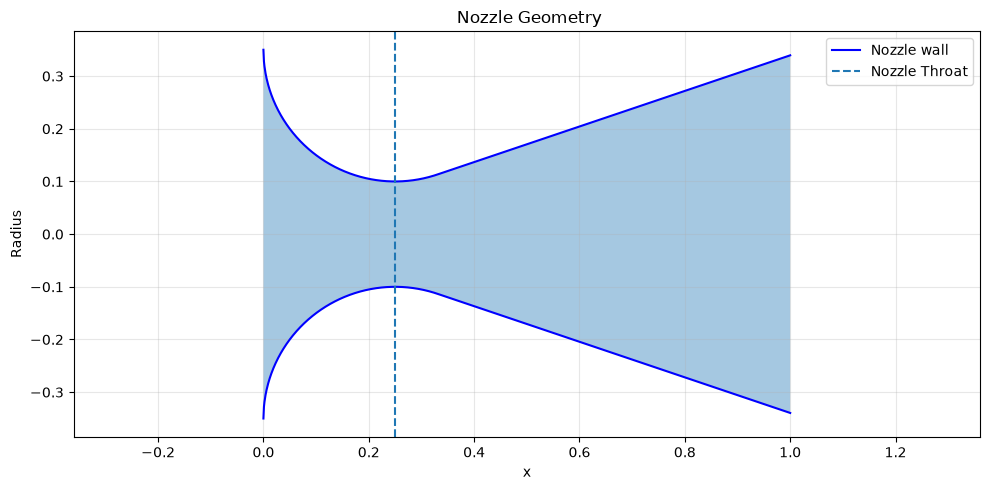

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import brentq


gamma = 1.4
Nozzle = np.loadtxt("Pnozzle.txt", delimiter=",")
Nozzle_Geom = []

x = Nozzle[:, 0]     
r = Nozzle[:, 1]
A = r * r * np.pi

Nozzle_Geom.append([x, r, A])

plt.figure(figsize=(10, 5))
plt.plot(x, r, color = 'b', label='Nozzle wall')
plt.plot(x, -r, color = 'b' )
plt.fill_between(x, -r, r)
plt.axvline( x=x[np.argmin(A)], linestyle='--', label='Nozzle Throat')
plt.xlabel("x")
plt.ylabel("Radius")
plt.title(" Nozzle Geometry")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW5/area-Mach%20number%20relation.png?raw=true" width="50%">


In [ ]:

#MachFromArea function takes in the Area ratio, gamma, 
def MachFromArea (A_ratio, gamma, branch):
    
    #This is the 'sub-function' that returns Area ratio subtracted by the given Area ratio to be optimized by Brentq, where solution will be zero.  
    def f (m_i):
        M = m_i ** 2 
        Relation = (1/M) * ((2/(gamma +1)) * (1 + ((gamma - 1)/2 * M))) ** ((gamma+1)/(gamma-1))
        return Relation - A_ratio ** 2
    
    if branch == "subsonic":
        return brentq(f, 1e-8, 1)
    else:
        return brentq(f, 1, 50)

print(MachFromArea(1.1, 1.4, "subsonic"))   
print(MachFromArea(2.0, 1.4, "supersonic"))  

def NozzlePressure (Mach, gamma, )
    

0.6923991394638542
2.197198121652185
